# 유기동물 입양 속도 예측

## 1. 문제 정의

- **배경:** 동물의 나이, 품종, 건강 상태 등에 따른 입양 속도 차이 존재
- **목표:** 동물 정보를 이용한 입양 속도 예측 및 모델별 성능 비교

### 라이브러리 및 환경 설정

In [1]:
from pathlib import Path
import hashlib, json, platform, time
from importlib.metadata import version
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from category_encoders import BinaryEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/train.csv").exists())
SEED, FOLDS, SEARCH_ITER = 123, 3, 6
MIN_IMPROVEMENT = 0.005
LABELS = [0, 1, 2, 3, 4]
OUT = ROOT / "results" / "current"
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
packages = ["pandas", "numpy", "scipy", "scikit-learn", "matplotlib", "xgboost", "lightgbm", "catboost", "category-encoders"]
manifest = {"python": platform.python_version(), "versions": {p: version(p) for p in packages},
            "seed": SEED, "folds": FOLDS, "search_iter": SEARCH_ITER,
            "selection_metric": "macro_f1", "min_improvement": MIN_IMPROVEMENT,
            "data_sha256": hashlib.sha256((ROOT / "data/train.csv").read_bytes()).hexdigest()}
(OUT / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
display(pd.Series(manifest["versions"], name="version"))
def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG / name, dpi=140, bbox_inches="tight")
    plt.show()

pandas                3.0.6
numpy                 2.4.6
scipy                1.17.1
scikit-learn          1.9.1
matplotlib           3.11.2
xgboost               3.2.0
lightgbm              4.7.0
catboost             1.2.10
category-encoders    2.11.1
Name: version, dtype: str

## 2. EDA

- 데이터 구성: 동물 프로필 14,993건, 24개 변수
- 주요 변수: 나이, 품종, 성별, 크기, 의료 처치 여부, 입양 비용, 사진 수
- 분석 범위: 단일 동물, 의료 처치 정보 확인 가능 표본의 개발 데이터
- Test 구성: 종별 20% 층화 분리 및 EDA 제외

### 데이터 구조 및 분석 대상 확인

In [2]:
raw = pd.read_csv(ROOT / "data/train.csv", keep_default_na=False, na_values=["", "nan"])
breeds = pd.read_csv(ROOT / "data/BreedLabels.csv")
MIXED_ID = int(breeds.loc[breeds.BreedName.eq("Mixed Breed"), "BreedID"].iloc[0])
assert raw.PetID.is_unique and raw.AdoptionSpeed.notna().all()
assert set(raw.AdoptionSpeed.unique()) == set(LABELS)
display(pd.DataFrame({"dtype": raw.dtypes.astype(str), "missing": raw.isna().sum(), "unique": raw.nunique()}))

eligible = raw.copy()
counts = [{"step": "raw", "rows": len(eligible)}]
rules = [("single_pet", lambda d: d.Quantity.eq(1)),
         ("known_health", lambda d: d.Health.ne(0)),
         ("known_sterilized", lambda d: d.Sterilized.ne(3)),
         ("known_dewormed", lambda d: d.Dewormed.ne(3)),
         ("known_vaccinated", lambda d: d.Vaccinated.ne(3))]
for name, rule in rules:
    eligible = eligible.loc[rule(eligible)].copy()
    counts.append({"step": name, "rows": len(eligible)})
filter_audit = pd.DataFrame(counts)
filter_audit["removed"] = filter_audit.rows.shift(1).sub(filter_audit.rows).fillna(0).astype(int)
display(filter_audit)
filter_audit.to_csv(OUT / "filter_audit.csv", index=False)

splits, split_records = {}, []
for species, type_id in [("dog", 1), ("cat", 2)]:
    subset = eligible.loc[eligible.Type.eq(type_id)]
    dev, test = train_test_split(subset, test_size=0.2, stratify=subset.AdoptionSpeed, random_state=SEED)
    assert set(dev.PetID).isdisjoint(test.PetID)
    splits[species] = (dev.copy(), test.copy())
    for role, frame in [("development", dev), ("test", test)]:
        split_records.extend({"species": species, "PetID": p, "split": role} for p in frame.PetID)
    overlap = set(dev.RescuerID) & set(test.RescuerID)
    print(f"{species}: development={len(dev)}, test={len(test)}, shared rescuers={len(overlap)}")
pd.DataFrame(split_records).to_csv(OUT / "split_ids.csv", index=False)

,dtype,missing,unique
Type,int64,0,2
Name,str,1257,9060
Age,int64,0,106
Breed1,int64,0,176
Breed2,int64,0,135
Gender,int64,0,3
Color1,int64,0,7
Color2,int64,0,7
Color3,int64,0,6
MaturitySize,int64,0,4


,step,rows,removed
0,raw,14993,0
1,single_pet,11565,3428
2,known_health,11565,0
3,known_sterilized,10219,1346
4,known_dewormed,9610,609
5,known_vaccinated,9436,174


dog: development=4179, test=1045, shared rescuers=268
cat: development=3369, test=843, shared rescuers=310


- 표본 기준 적용 후 9,436건 확보 및 개 5,224건, 고양이 4,212건 구성
- 약 37.1%의 표본 제외에 따른 전체 동물 집단으로의 일반화 제한

### 클래스 분포 및 특성 분포

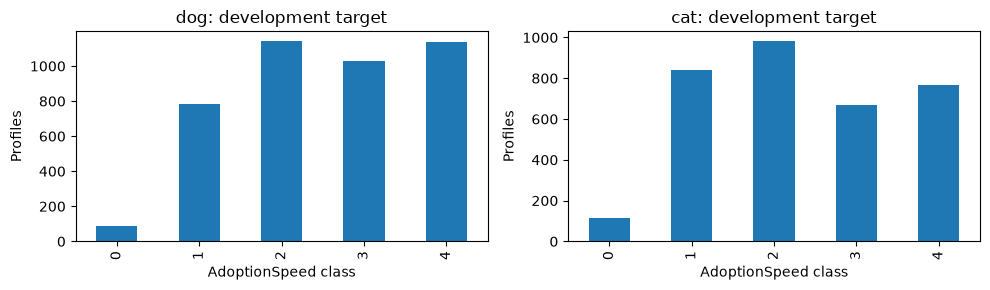

,species,class,count,fraction
0,dog,0,86,0.020579
1,dog,1,785,0.187844
2,dog,2,1141,0.273032
3,dog,3,1030,0.246470
4,dog,4,1137,0.272075
5,cat,0,114,0.033838
6,cat,1,841,0.249629
7,cat,2,981,0.291184
8,cat,3,667,0.197982
9,cat,4,766,0.227367


### dog: 수치형 분포 및 범주형 관계

,count,mean,std,min,50%,90%,99%,max
Age,4179.0,12.746829,20.620544,0.0,3.0,36.0,96.0,238.0
Fee,4179.0,28.110553,88.871197,0.0,0.0,100.0,500.0,1000.0
PhotoAmt,4179.0,3.618330,3.300283,0.0,3.0,7.0,16.0,30.0


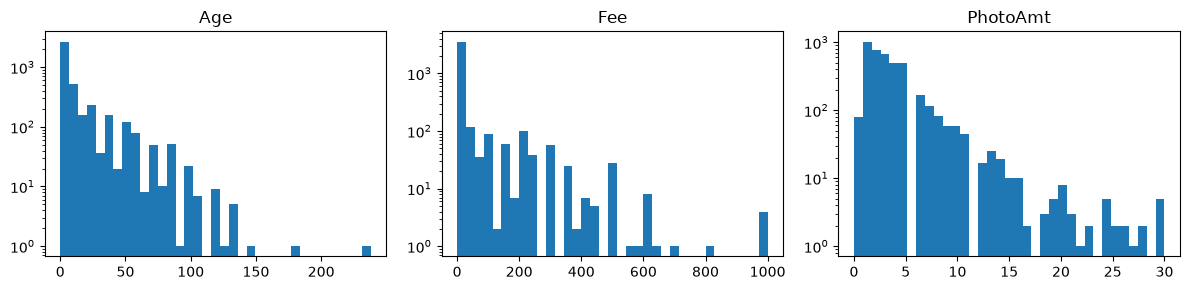

AdoptionSpeed,0,1,2,3,4
Sterilized,,,,,
1,0.023558,0.101543,0.199838,0.255077,0.419984
2,0.019335,0.223881,0.303596,0.242877,0.210312


AdoptionSpeed,0,1,2,3,4
FurLength,,,,,
1,0.016209,0.160848,0.256858,0.256442,0.309643
2,0.022843,0.218274,0.291878,0.237944,0.229061
3,0.055838,0.274112,0.319797,0.192893,0.157360


### cat: 수치형 분포 및 범주형 관계

,count,mean,std,min,50%,90%,99%,max
Age,3369.0,7.987237,13.594379,0.0,4.0,18.0,69.96,212.0
Fee,3369.0,22.106560,69.130004,0.0,0.0,80.0,350.00,800.0
PhotoAmt,3369.0,4.010092,3.470253,0.0,3.0,7.0,17.32,30.0


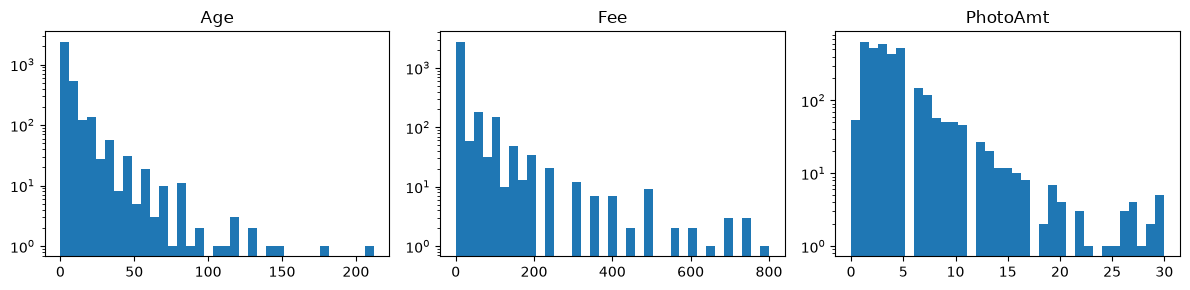

AdoptionSpeed,0,1,2,3,4
Sterilized,,,,,
1,0.023407,0.133940,0.228869,0.226268,0.387516
2,0.036923,0.283846,0.309615,0.189615,0.180000


AdoptionSpeed,0,1,2,3,4
FurLength,,,,,
1,0.030464,0.230658,0.291103,0.204062,0.243714
2,0.029712,0.276695,0.294336,0.187558,0.211699
3,0.084821,0.294643,0.276786,0.191964,0.151786


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
eda_rows = []
for ax, (species, (dev, _)) in zip(axes, splits.items()):
    counts = dev.AdoptionSpeed.value_counts().reindex(LABELS, fill_value=0)
    counts.plot.bar(ax=ax, title=f"{species}: development target")
    ax.set_xlabel("AdoptionSpeed class"); ax.set_ylabel("Profiles")
    eda_rows.extend({"species": species, "class": k, "count": v, "fraction": v / len(dev)} for k, v in counts.items())
savefig("target_distribution.png")
display(pd.DataFrame(eda_rows))
pd.DataFrame(eda_rows).to_csv(OUT / "development_distribution.csv", index=False)

for species, (dev, _) in splits.items():
    display(Markdown(f"### {species}: 수치형 분포 및 범주형 관계"))
    display(dev[["Age", "Fee", "PhotoAmt"]].describe(percentiles=[.5, .9, .99]).T)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    for col, ax in zip(["Age", "Fee", "PhotoAmt"], axes):
        ax.hist(dev[col], bins=35); ax.set_title(col); ax.set_yscale("log")
    savefig(f"{species}_numeric.png")
    display(pd.crosstab(dev.Sterilized, dev.AdoptionSpeed, normalize="index").reindex(columns=LABELS))
    display(pd.crosstab(dev.FurLength, dev.AdoptionSpeed, normalize="index").reindex(columns=LABELS))

- 개발 데이터 클래스 0 비중: 개 2.1%, 고양이 3.4%로 소수 클래스 불균형 확인
- 나이, 입양 비용, 사진 수의 비대칭 분포 및 큰 값이 드물게 나타나는 긴 꼬리 확인

## 3. 전처리

- 품종 Binary Encoding 및 성별, 의료 처치, 크기 One-hot Encoding
- 이름 기입 여부와 품종 조합 기반 파생변수 구성
- 개 털 길이, 건강 상태의 원본 코드 활용 및 고양이 털 길이 One-hot Encoding
- 입양 비용, 사진 수 Min-Max Scaling 및 ID, 설명문 등 입력 제외
- 교차검증 학습 fold 내부 전처리 fit을 통한 평가 데이터 정보 유입 방지

In [4]:
CATEGORICAL = ["Gender", "Vaccinated", "Dewormed", "Sterilized", "MaturitySize"]
RAW_FEATURES = ["Name", "Age", "Breed1", "Breed2", "Gender", "MaturitySize", "FurLength", "Vaccinated", "Dewormed", "Sterilized", "Health", "Fee", "PhotoAmt"]

def make_features(frame):
    x = frame[RAW_FEATURES].copy()
    x["has_name"] = x.Name.notna().astype(int)
    x["breed_proxy"] = (x.Breed1.ne(MIXED_ID) & x.Breed1.ne(0) & x.Breed2.eq(0)).astype(int)
    x["Breed1"] = x.Breed1.astype(str)
    return x.drop(columns=["Name", "Breed2"])

def make_pipeline(species, model):
    categorical = CATEGORICAL + (["FurLength"] if species == "cat" else [])
    numeric = ["Age", "Health", "has_name", "breed_proxy"] + (["FurLength"] if species == "dog" else [])
    pre = ColumnTransformer([
        ("breed", BinaryEncoder(cols=["Breed1"], handle_unknown="value", handle_missing="value"), ["Breed1"]),
        ("category", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical),
        ("scale", MinMaxScaler(), ["Fee", "PhotoAmt"]),
        ("numeric", "passthrough", numeric)], remainder="drop", sparse_threshold=0)
    return Pipeline([("features", FunctionTransformer(make_features, validate=False)),
                     ("preprocess", pre), ("model", clone(model))])

MODELS = {
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, learning_rate=.1, max_depth=3, random_state=SEED),
    "AdaBoost": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=SEED), n_estimators=100, learning_rate=.1, random_state=SEED),
    "LightGBM": LGBMClassifier(n_estimators=100, learning_rate=.05, num_leaves=31, random_state=SEED, n_jobs=1, verbosity=-1),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=3, learning_rate=.1, objective="multi:softprob", eval_metric="mlogloss", random_state=SEED, n_jobs=1),
    "CatBoost": CatBoostClassifier(iterations=100, depth=4, learning_rate=.1, random_seed=SEED, thread_count=1, verbose=False, allow_writing_files=False),
}
cv = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)
def evaluate_cv(pipe, frame, balanced=False):
    x, y = frame[RAW_FEATURES], frame.AdoptionSpeed
    records = []
    for fold, (train_idx, valid_idx) in enumerate(cv.split(x, y)):
        fitted = clone(pipe)
        weights = {"model__sample_weight": compute_sample_weight("balanced", y.iloc[train_idx])} if balanced else {}
        start = time.perf_counter()
        fitted.fit(x.iloc[train_idx], y.iloc[train_idx], **weights)
        pred = fitted.predict(x.iloc[valid_idx]).reshape(-1)
        train_pred = fitted.predict(x.iloc[train_idx]).reshape(-1)
        records.append({"fold": fold, "macro_f1": f1_score(y.iloc[valid_idx], pred, labels=LABELS, average="macro", zero_division=0),
                        "accuracy": accuracy_score(y.iloc[valid_idx], pred),
                        "train_macro_f1": f1_score(y.iloc[train_idx], train_pred, labels=LABELS, average="macro", zero_division=0),
                        "seconds": time.perf_counter() - start,
                        **{f"recall_{k}": float((pred[y.iloc[valid_idx].to_numpy() == k] == k).mean()) for k in LABELS}})
    return pd.DataFrame(records)

def summarize(scores):
    return {"cv_macro_f1": scores.macro_f1.mean(), "cv_std": scores.macro_f1.std(ddof=1),
            "cv_accuracy": scores.accuracy.mean(), "train_macro_f1": scores.train_macro_f1.mean(),
            "fit_seconds": scores.seconds.sum(),
            **{f"cv_recall_{k}": scores[f"recall_{k}"].mean() for k in LABELS}}

## 4. 모델 비교 및 후보 선정

- 수치형, 범주형 특성의 비선형 관계와 상호작용 학습을 위한 트리 기반 모델 검토
- 여러 트리의 순차 결합을 통한 예측 오차 보완 가능성을 기준으로 부스팅 5종 비교
- 동일한 층화 3-fold의 Macro F1 기준 후보 선정 및 Dummy 기준선 비교

In [5]:
baseline_rows, all_folds = [], []
for species, (dev, _) in splits.items():
    for name, model in {"Dummy": DummyClassifier(strategy="most_frequent"), **MODELS}.items():
        scores = evaluate_cv(make_pipeline(species, model), dev)
        scores = scores.assign(species=species, stage="baseline", model=name)
        all_folds.append(scores)
        baseline_rows.append({"species": species, "model": name, **summarize(scores)})
        print(species, name, round(scores.macro_f1.mean(), 4), flush=True)
baseline = pd.DataFrame(baseline_rows)
baseline.to_csv(OUT / "baseline_cv.csv", index=False)
display(baseline.sort_values(["species", "cv_macro_f1"], ascending=[True, False]))
candidates = {s: baseline.query("species == @s and model != 'Dummy'").sort_values(["cv_macro_f1", "model"], ascending=[False, True]).head(2).model.tolist() for s in splits}
print("Tuning candidates:", candidates)

dog Dummy 0.0858


dog GradientBoosting 0.3156


dog AdaBoost 0.2637


dog LightGBM 0.3267


dog XGBoost 0.3103


...

cat LightGBM 0.2864


cat XGBoost 0.2755


cat CatBoost 0.2732


,species,model,cv_macro_f1,cv_std,cv_accuracy,train_macro_f1,fit_seconds,cv_recall_0,cv_recall_1,cv_recall_2,cv_recall_3,cv_recall_4
9,cat,LightGBM,0.286425,0.008478,0.353517,0.678562,1.226335,0.026316,0.378110,0.394495,0.170942,0.481694
7,cat,GradientBoosting,0.280475,0.005927,0.365687,0.495658,3.254371,0.000000,0.399517,0.424057,0.119932,0.522263
10,cat,XGBoost,0.275536,0.009587,0.367468,0.387732,0.508431,0.000000,0.405469,0.429154,0.091457,0.541850
11,cat,CatBoost,0.273160,0.008386,0.361828,0.353562,0.981677,0.000000,0.372178,0.430173,0.106445,0.539165
8,cat,AdaBoost,0.259861,0.006333,0.349659,0.265438,0.947206,0.000000,0.299678,0.464832,0.095988,0.530004
6,cat,Dummy,0.090207,0.000000,0.291184,0.090207,0.140908,0.000000,0.000000,1.000000,0.000000,0.000000
3,dog,LightGBM,0.326654,0.018980,0.405121,0.661030,1.328477,0.046388,0.286601,0.428584,0.237900,0.642040
1,dog,GradientBoosting,0.315588,0.005587,0.400574,0.507354,3.526606,0.023399,0.277734,0.433838,0.234959,0.630607
4,dog,XGBoost,0.310284,0.007757,0.404642,0.422083,0.641553,0.011905,0.239512,0.468007,0.228160,0.644679
5,dog,CatBoost,0.306601,0.003013,0.407274,0.362122,1.195608,0.000000,0.229305,0.509223,0.219402,0.628848


Tuning candidates: {'dog': ['LightGBM', 'GradientBoosting'], 'cat': ['LightGBM', 'GradientBoosting']}


- 개, 고양이 모두 LightGBM과 Gradient Boosting의 상위 2개 후보 선정
- 초기 LightGBM의 CV Macro F1: 개 0.3267, 고양이 0.2864로 비교 대상 중 최고 평균값 기록

## 5. 상위 후보 파라미터 튜닝

- 상위 2개 후보별 6개 설정의 랜덤 탐색 및 동일한 3-fold 검증
- 학습률, 트리 수, 깊이 또는 리프 수 등 모델별 파라미터 조정

In [6]:
spaces = {
    "GradientBoosting": {"model__n_estimators": [80, 140], "model__learning_rate": [.03, .1], "model__max_depth": [2, 3], "model__min_samples_leaf": [3, 10]},
    "AdaBoost": {"model__n_estimators": [80, 160], "model__learning_rate": [.05, .2, .5], "model__estimator__max_depth": [1, 2, 3]},
    "LightGBM": {"model__n_estimators": [80, 160], "model__learning_rate": [.03, .1], "model__num_leaves": [15, 31], "model__min_child_samples": [20, 50], "model__subsample": [.8, 1.0], "model__subsample_freq": [1]},
    "XGBoost": {"model__n_estimators": [80, 160], "model__learning_rate": [.03, .1], "model__max_depth": [2, 4], "model__subsample": [.8, 1.0], "model__colsample_bytree": [.8, 1.0]},
    "CatBoost": {"model__iterations": [80, 160], "model__learning_rate": [.03, .1], "model__depth": [3, 5], "model__bootstrap_type": ["Bernoulli"], "model__subsample": [.8, 1.0]},
}
tuned_rows, searches = [], {}
for species, names in candidates.items():
    dev, _ = splits[species]
    for name in names:
        search = RandomizedSearchCV(make_pipeline(species, MODELS[name]), spaces[name], n_iter=SEARCH_ITER,
                                    scoring="f1_macro", cv=cv, random_state=SEED, n_jobs=1, error_score="raise", return_train_score=True)
        search.fit(dev[RAW_FEATURES], dev.AdoptionSpeed)
        searches[species, name] = search
        pd.DataFrame(search.cv_results_).to_csv(OUT / f"{species}_{name}_search.csv", index=False)
        tuned_rows.append({"species": species, "model": name, "cv_macro_f1": search.best_score_,
                           "best_params": json.dumps(search.best_params_, sort_keys=True)})
        print(species, name, search.best_score_, search.best_params_, flush=True)
tuned = pd.DataFrame(tuned_rows)
tuned.to_csv(OUT / "tuning_summary.csv", index=False)
display(tuned)

dog LightGBM 0.33381612763501867 {'model__subsample_freq': 1, 'model__subsample': 1.0, 'model__num_leaves': 31, 'model__n_estimators': 160, 'model__min_child_samples': 20, 'model__learning_rate': 0.03}


dog GradientBoosting 0.3093949391041293 {'model__n_estimators': 140, 'model__min_samples_leaf': 3, 'model__max_depth': 2, 'model__learning_rate': 0.1}


cat LightGBM 0.29172840030131275 {'model__subsample_freq': 1, 'model__subsample': 1.0, 'model__num_leaves': 31, 'model__n_estimators': 160, 'model__min_child_samples': 20, 'model__learning_rate': 0.03}


cat GradientBoosting 0.2890189231076522 {'model__n_estimators': 140, 'model__min_samples_leaf': 3, 'model__max_depth': 2, 'model__learning_rate': 0.1}


,species,model,cv_macro_f1,best_params
0,dog,LightGBM,0.333816,"{""model__learning_rate"": 0.03, ""model__min_chi..."
1,dog,GradientBoosting,0.309395,"{""model__learning_rate"": 0.1, ""model__max_dept..."
2,cat,LightGBM,0.291728,"{""model__learning_rate"": 0.03, ""model__min_chi..."
3,cat,GradientBoosting,0.289019,"{""model__learning_rate"": 0.1, ""model__max_dept..."


- 튜닝 LightGBM의 CV Macro F1: 개 0.3338, 고양이 0.2917 기록
- Gradient Boosting 튜닝의 종별 상이한 결과: 개 0.3156 → 0.3094 하락, 고양이 0.2805 → 0.2890 상승

### 초기 설정 및 튜닝 설정 비교

In [7]:
comparison = pd.concat([baseline.query("model != 'Dummy'")[["species", "model", "cv_macro_f1"]].assign(stage="baseline"),
                        tuned[["species", "model", "cv_macro_f1"]].assign(stage="tuned")], ignore_index=True)
selected = {}
for species in splits:
    row = comparison.query("species == @species").sort_values(["cv_macro_f1", "model", "stage"], ascending=[False, True, True]).iloc[0]
    pipe = make_pipeline(species, MODELS[row.model]) if row.stage == "baseline" else clone(searches[species, row.model].best_estimator_)
    selected[species] = {"model": row.model, "stage": row.stage, "pipe": pipe}
comparison.to_csv(OUT / "selection_comparison.csv", index=False)
selection_summary = comparison.sort_values(["species", "cv_macro_f1", "model", "stage"], ascending=[True, False, True, True]).groupby("species", sort=False).head(1)
display(selection_summary)

,species,model,cv_macro_f1,stage
12,cat,LightGBM,0.291728,tuned
10,dog,LightGBM,0.333816,tuned


- 초기, 튜닝 설정의 CV Macro F1 비교에 따른 개, 고양이 LightGBM 선정
- 제한된 후보, 탐색 범위의 선택 결과로 전체 알고리즘 대비 최적성 판단 제외

## 6. 추가 성능 개선 시도

- 클래스 불균형 대응을 위한 학습 가중치 조정
- 비가중 모델 대비 CV Macro F1 0.005 이상 상승 기준의 채택 여부 결정

In [8]:
improvement_rows, decisions = [], {}
for species, spec in selected.items():
    dev, _ = splits[species]
    variants = {}
    for balanced in [False, True]:
        scores = evaluate_cv(spec["pipe"], dev, balanced=balanced)
        all_folds.append(scores.assign(species=species, stage="balanced" if balanced else "selected", model=spec["model"]))
        variants[balanced] = summarize(scores)
        improvement_rows.append({"species": species, "model": spec["model"], "balanced": balanced, **variants[balanced]})
    delta = variants[True]["cv_macro_f1"] - variants[False]["cv_macro_f1"]
    accept = bool(delta >= MIN_IMPROVEMENT)
    decisions[species] = {"model": spec["model"], "stage": spec["stage"], "balanced": accept,
                          "cv_gain_balanced": delta, "model_params": spec["pipe"].named_steps["model"].get_params()}
    print(f"{species}: balanced CV delta={delta:+.4f}, accepted={accept}")
improvement = pd.DataFrame(improvement_rows)
display(improvement)
improvement.to_csv(OUT / "improvement_cv.csv", index=False)
pd.concat(all_folds, ignore_index=True).to_csv(OUT / "fold_metrics.csv", index=False)
(OUT / "decisions.json").write_text(json.dumps(decisions, indent=2, default=str), encoding="utf-8")

dog: balanced CV delta=-0.0249, accepted=False


cat: balanced CV delta=+0.0128, accepted=True


,species,model,balanced,cv_macro_f1,cv_std,cv_accuracy,train_macro_f1,fit_seconds,cv_recall_0,cv_recall_1,cv_recall_2,cv_recall_3,cv_recall_4
0,dog,LightGBM,False,0.333816,0.014606,0.412778,0.655331,2.072657,0.046388,0.295531,0.429452,0.255373,0.647318
1,dog,LightGBM,True,0.308932,0.016538,0.373534,0.575766,2.096745,0.069376,0.458610,0.245418,0.255376,0.573439
2,cat,LightGBM,False,0.291728,0.002860,0.360641,0.666533,1.970423,0.026316,0.395967,0.395515,0.169427,0.493490
3,cat,LightGBM,True,0.304561,0.007042,0.335114,0.622598,1.928557,0.289474,0.367429,0.246687,0.241371,0.501323


1418

- 고양이 CV Macro F1 0.2917 → 0.3046 상승에 따른 가중치 채택
- 개 CV Macro F1 0.3338 → 0.3089 하락에 따른 비가중 설정 유지

## 7. 최종 모델의 Test 평가

- 선택 설정 고정 후 전체 개발 데이터 재학습 및 Test 예측
- Accuracy, Macro F1, 클래스별 Precision/Recall/F1 및 혼동행렬 확인

### dog: LightGBM

,precision,recall,f1-score,support
0,0.000000,0.000000,0.000000,22.0
1,0.397163,0.285714,0.332344,196.0
2,0.362434,0.479021,0.412651,286.0
3,0.369318,0.252918,0.300231,257.0
4,0.511494,0.626761,0.563291,284.0
macro avg,0.328082,0.328883,0.321703,1045.0
weighted avg,0.403521,0.417225,0.402193,1045.0


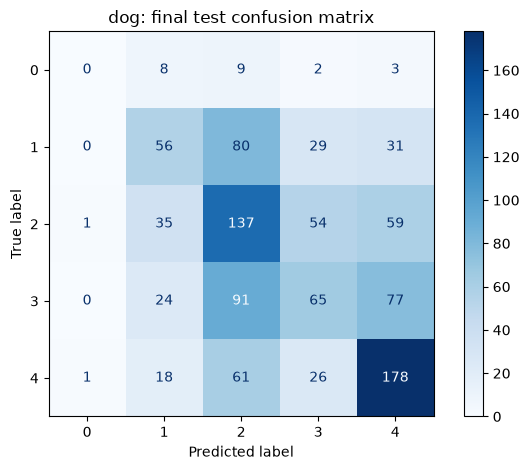

### cat: LightGBM

,precision,recall,f1-score,support
0,0.097222,0.250000,0.140000,28.0
1,0.326271,0.364929,0.344519,211.0
2,0.325153,0.216327,0.259804,245.0
3,0.305344,0.239521,0.268456,167.0
4,0.423237,0.531250,0.471132,192.0
macro avg,0.295445,0.320405,0.296782,843.0
weighted avg,0.336277,0.330961,0.326874,843.0


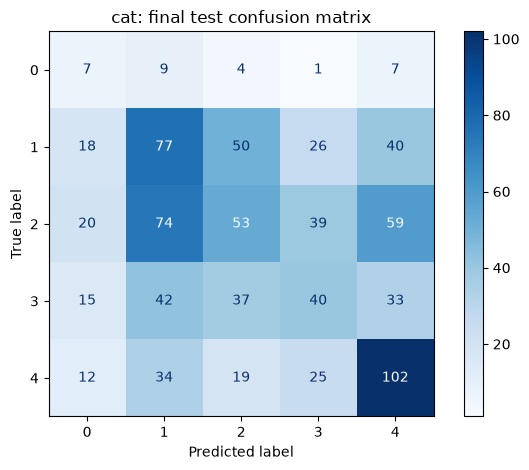

,species,model,stage,balanced,test_n,accuracy,macro_f1
0,dog,LightGBM,tuned,False,1045,0.417225,0.321703
1,cat,LightGBM,tuned,True,843,0.330961,0.296782


In [9]:
final_rows = []
for species, spec in selected.items():
    dev, test = splits[species]
    fitted = clone(spec["pipe"])
    weights = {"model__sample_weight": compute_sample_weight("balanced", dev.AdoptionSpeed)} if decisions[species]["balanced"] else {}
    fitted.fit(dev[RAW_FEATURES], dev.AdoptionSpeed, **weights)
    pred = fitted.predict(test[RAW_FEATURES]).reshape(-1).astype(int)
    report = classification_report(test.AdoptionSpeed, pred, labels=LABELS, output_dict=True, zero_division=0)
    report_df = pd.DataFrame({k: v for k, v in report.items() if isinstance(v, dict)}).T
    report_df.to_csv(OUT / f"{species}_classification_report.csv")
    display(Markdown(f"### {species}: {spec['model']}"))
    display(report_df)
    final_rows.append({"species": species, "model": spec["model"], "stage": spec["stage"], "balanced": decisions[species]["balanced"],
                       "test_n": len(test), "accuracy": accuracy_score(test.AdoptionSpeed, pred),
                       "macro_f1": f1_score(test.AdoptionSpeed, pred, labels=LABELS, average="macro", zero_division=0)})
    pd.DataFrame({"PetID": test.PetID, "actual": test.AdoptionSpeed, "predicted": pred}).to_csv(OUT / f"{species}_predictions.csv", index=False)
    ConfusionMatrixDisplay.from_predictions(test.AdoptionSpeed, pred, labels=LABELS, cmap="Blues")
    plt.title(f"{species}: final test confusion matrix")
    savefig(f"{species}_confusion.png")
final_metrics = pd.DataFrame(final_rows)
final_metrics.to_csv(OUT / "metrics.csv", index=False)
display(final_metrics)
assert final_metrics[["accuracy", "macro_f1"]].ge(0).all().all()
assert final_metrics[["accuracy", "macro_f1"]].le(1).all().all()

- 개 Test Accuracy 0.4172, Macro F1 0.3217 기록
- 고양이 Test Accuracy 0.3310, Macro F1 0.2968 기록

## 8. 결과 요약

- 동일한 교차검증 조건에서 모델 비교 및 파라미터 튜닝 수행
- 비교한 설정 중 CV Macro F1이 가장 높은 LightGBM을 개, 고양이의 최종 후보로 선정

### 클래스 가중치 적용 결과

In [10]:
weight_summary = improvement.pivot(index="species", columns="balanced", values="cv_macro_f1")
weight_summary = weight_summary.reindex(["dog", "cat"]).rename(columns={False: "적용 전 CV Macro F1", True: "적용 후 CV Macro F1"})
weight_summary["최종 결정"] = final_metrics.set_index("species")["balanced"].map({False: "성능 하락에 따른 미적용", True: "성능 개선에 따른 적용"})
weight_summary.index = weight_summary.index.map({"dog": "개", "cat": "고양이"})
weight_summary.index.name = "대상"
weight_summary.columns.name = None
display(weight_summary.round(4))

,적용 전 CV Macro F1,적용 후 CV Macro F1,최종 결정
대상,,,
개,0.3338,0.3089,성능 하락에 따른 미적용
고양이,0.2917,0.3046,성능 개선에 따른 적용


- 가중치 적용 효과의 종별 차이 확인 및 검증 결과에 따른 최종 설정 결정

### 최종 Test 평가

In [11]:
test_summary = final_metrics[["species", "model", "balanced", "accuracy", "macro_f1"]].copy()
test_summary["species"] = test_summary["species"].map({"dog": "개", "cat": "고양이"})
test_summary["balanced"] = test_summary["balanced"].map({False: "미적용", True: "적용"})
test_summary = test_summary.rename(columns={"species": "대상", "model": "최종 모델", "balanced": "클래스 가중치", "accuracy": "Accuracy", "macro_f1": "Macro F1"}).set_index("대상")
display(test_summary.round(4))

,최종 모델,클래스 가중치,Accuracy,Macro F1
대상,,,,
개,LightGBM,미적용,0.4172,0.3217
고양이,LightGBM,적용,0.3310,0.2968


- 모델과 가중치 적용 여부를 결정한 후, 선택에 사용하지 않은 Test 데이터로 최종 성능 확인
- 일부 클래스의 낮은 Recall로 클래스별 예측 성능 차이 확인
- 추가 개선 방향: 예측이 어려운 클래스의 특성 분석 및 다른 데이터 분할 조건에서의 성능 검증